**Imports**

In [27]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numba import njit, prange

In [28]:
data = pandas.read_csv('sdss_cutout.csv')
z = data['Z'].values
z_mask = (z > 0.08) & (z < 0.12)
data = data[z_mask].reset_index(drop=True)
#print(data)
u_mag = data['phot_u'].values
r_mag = data['phot_r'].values
color = u_mag - r_mag

red_gal = data[color > 2.3].reset_index(drop=True)
blue_gal = data[color <= 2.3].reset_index(drop=True)

red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

In [29]:
# Since the red and blue samples have different sized we need to use those when creating our random samples.
red_len = len(red_gal)
blue_len = len(blue_gal)

# According to the NumPy documentation, this is the recommended way to create a sample from a uniform distribution.
rand = np.random.default_rng()

red_ra_rand = rand.uniform(130, 230, red_len)
red_dec_rand = rand.uniform(5, 65, red_len)

blue_ra_rand = rand.uniform(130, 230, blue_len)
blue_dec_rand = rand.uniform(5, 65, blue_len)

omega_bins = np.geomspace(0.003, 0.3, 11)

In [30]:
# To use our samples with the logarithmically spaced bins in radians, we have to convert our coordinates into sperical ones.
def ra_dec_to_spherical(ra, dec):
    phi = np.pi * (ra/180)
    theta = np.pi/2 - np.pi * (dec/180)
    return phi, theta

In [31]:
# Conversion

red_phi, red_theta = ra_dec_to_spherical(red_gal_ra, red_gal_dec)
blue_phi, blue_theta = ra_dec_to_spherical(blue_gal_ra, blue_gal_dec)

red_phi_rand, red_theta_rand = ra_dec_to_spherical(red_ra_rand, red_dec_rand)
blue_phi_rand, blue_theta_rand = ra_dec_to_spherical(blue_ra_rand, blue_dec_rand)

In [ ]:
@njit(parallel=True)
def count_pairs(delta1, delta2, alpha1, alpha2, edges, auto=False):
    bin_num = len(edges) - 1
    counts = np.zeros(bin_num, dtype=np.int64)

    for i in prange(len(alpha1)):
        cos_a = np.cos(alpha1[i])
        sin_a = np.sin(alpha1[i])
        delta = delta1[i]

        j_start = i + 1 if auto else 0

        for j in range(j_start, len(alpha2)):
            cos_omega = (cos_a * np.cos(alpha2[j]) + np.cos(delta - delta2[j]) * sin_a * np.sin(alpha2[j]))

            # Without the clamp we get quite a lot of NaNs in our results. Possibly due to floating point errors.
            if cos_omega > 1.0:
                cos_omega = 1.0
            elif cos_omega < -1.0:
                cos_omega = -1.0

            omega = np.arccos(cos_omega)

            for k in range(bin_num):
                if edges[k] <= omega < edges[k + 1]:
                    counts[k] += 1
                    break
    return counts

In [33]:
red_DD = count_pairs(red_phi, red_phi, red_theta, red_theta, omega_bins, auto=True)
red_RR = count_pairs(red_phi_rand, red_phi_rand, red_theta_rand, red_theta_rand, omega_bins, auto=True)
red_DR = count_pairs(red_phi, red_phi_rand, red_theta, red_theta_rand, omega_bins, auto=False)

In [34]:
blue_DD = count_pairs(blue_phi, blue_phi, blue_theta, blue_theta, omega_bins, auto=True)
blue_RR = count_pairs(blue_phi_rand, blue_phi_rand, blue_theta_rand, blue_theta_rand, omega_bins, auto=True)
blue_DR = count_pairs(blue_phi, blue_phi_rand, blue_theta, blue_theta_rand, omega_bins, auto=False)

In [35]:
print(red_DD)
print(red_RR)
print(red_DR)

[    99952    216039    481213   1101258   2560821   5941622  13585364
  30352301  67140599 136381270]
[    58027    144906    363869    906483   2247318   5531395  13484442
  32180842  73719477 158147222]
[   107002    268004    674241   1677110   4173085  10276383  24971927
  59405775 137023045 300546264]


In [36]:
print(blue_DD)
print(blue_RR)
print(blue_DR)

[   19100    44920   106505   255838   605574  1437362  3383836  7770198
 17501230 35849778]
[   14500    36456    90744   227887   564907  1393051  3397200  8118400
 18624517 40098214]
[   27287    68539   170870   428058  1061454  2624598  6408066 15351766
 35545761 78147960]


In [37]:
def landy_szalay(DD, RR, DR, num):
    return 1 + DD/RR - (num -1)/num * DR/RR

In [38]:
red_xi = landy_szalay(red_DD, red_RR, red_DR, red_len)
print(red_xi)

blue_xi = landy_szalay(blue_DD, blue_RR, blue_DR, blue_len)
print(blue_xi)

[ 0.87853523  0.6414187   0.46954293  0.36477093  0.28261368  0.21636557
  0.15560827  0.09721148  0.05207972 -0.03802038]
[ 0.4354411   0.35218484  0.29075873  0.24433625  0.1930616   0.14780591
  0.10984941  0.06618743  0.03120366 -0.0548005 ]


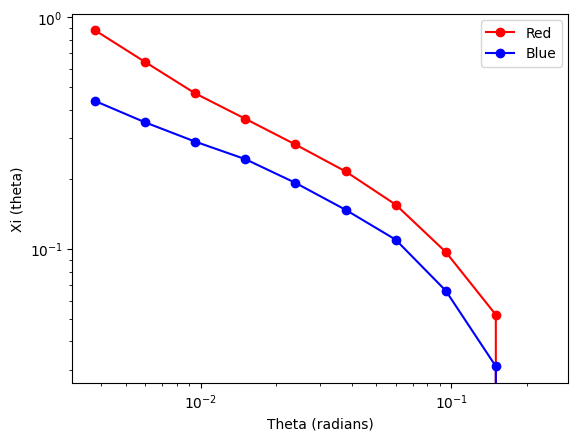

In [ ]:
# We need to compute the geometric mean first. We can't use the arithmic mean since our bins are log spaced.
bin_midpoints = np.sqrt(omega_bins[:-1] * omega_bins[1:])
#degree_points = np.degrees(bin_midpoints)
plt.loglog(bin_midpoints, red_xi, 'o-', c='firebrick', label='Red')
plt.loglog(bin_midpoints, blue_xi, 'o-', c='steelblue', label='Blue')
plt.xlabel('Theta (radians)')
plt.ylabel('Xi (theta)')
plt.legend()
plt.show()

**Task 6**

In [40]:
jack_knife_regions = 6
# We only slice the data in the RA direction to save on computation time.
ra_edges = np.linspace(130, 230, jack_knife_regions + 1)

red_region = np.digitize(red_gal_ra, ra_edges[1:-1])
red_region_rand = np.digitize(red_ra_rand, ra_edges[1:-1])

blue_region = np.digitize(blue_gal_ra, ra_edges[1:-1])
blue_region_rand = np.digitize(blue_ra_rand, ra_edges[1:-1])

red_xi_samples = []
blue_xi_samples = []

In [41]:
for k in range(jack_knife_regions):
    red_mask = red_region != k
    red_mask_rand = red_region_rand != k

    blue_mask = blue_region != k
    blue_mask_rand = blue_region_rand != k

    red_DD_k = count_pairs(red_phi[red_mask], red_phi[red_mask], red_theta[red_mask], red_theta[red_mask], omega_bins, auto=True)
    red_RR_k = count_pairs(red_phi_rand[red_mask_rand], red_phi_rand[red_mask_rand], red_theta_rand[red_mask_rand], red_theta_rand[red_mask_rand], omega_bins, auto=True)
    red_DR_k = count_pairs(red_phi[red_mask], red_phi_rand[red_mask_rand], red_theta[red_mask], red_theta_rand[red_mask_rand], omega_bins, auto=False)

    blue_DD_k = count_pairs(blue_phi[blue_mask], blue_phi[blue_mask], blue_theta[blue_mask], blue_theta[blue_mask], omega_bins, auto=True)
    blue_RR_k = count_pairs(blue_phi_rand[blue_mask_rand], blue_phi_rand[blue_mask_rand], blue_theta_rand[blue_mask_rand], blue_theta_rand[blue_mask_rand], omega_bins, auto=True)
    blue_DR_k = count_pairs(blue_phi[blue_mask], blue_phi_rand[blue_mask_rand], blue_theta[blue_mask], blue_theta_rand[blue_mask_rand], omega_bins, auto=False)

    xi_red_k = landy_szalay(red_DD_k, red_RR_k, red_DR_k, np.sum(red_mask))
    xi_blue_k = landy_szalay(blue_DD_k, blue_RR_k, blue_DR_k, np.sum(blue_mask))

    red_xi_samples.append(xi_red_k)
    blue_xi_samples.append(xi_blue_k)

In [42]:
red_xi_all = np.array(red_xi_samples)
blue_xi_all = np.array(blue_xi_samples)

red_xi_mean = np.mean(red_xi_all, axis=0)
red_xi_std = np.std(red_xi_all, axis=0)

blue_xi_mean = np.mean(blue_xi_all, axis=0)
blue_xi_std = np.std(blue_xi_all, axis=0)

# From the equation in the lecture.
red_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((red_xi_all - red_xi_mean)**2, axis=0)
red_xi_err = np.sqrt(red_xi_var)

blue_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((blue_xi_all - blue_xi_mean)**2, axis=0)
blue_xi_err = np.sqrt(blue_xi_var)

print("Red xi error:", red_xi_err)
print("Blue xi error:", blue_xi_err)

Red xi error: [0.10486458 0.07538022 0.05624892 0.05541413 0.04664613 0.03954968
 0.03511184 0.03244348 0.03169047 0.03922657]
Blue xi error: [0.04194658 0.02984982 0.02780554 0.02301372 0.02480827 0.02271278
 0.02142705 0.01981382 0.02458022 0.05197368]


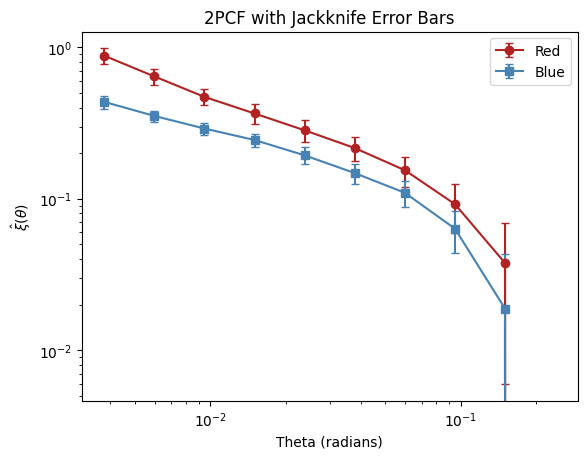

In [43]:
fig, ax = plt.subplots()

ax.errorbar(bin_midpoints, red_xi_mean, yerr=red_xi_err, fmt='o-', c='firebrick', capsize=3, label='Red')
ax.errorbar(bin_midpoints, blue_xi_mean, yerr=blue_xi_err, fmt='s-', c='steelblue', capsize=3, label='Blue')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Theta (radians)')
ax.set_ylabel(r'$\hat{\xi}(\theta)$')
ax.set_title('2PCF with Jackknife Error Bars')
ax.legend()
plt.show()